In [ ]:
DISTRICT_NAME = 'Belgaum'
YEAR = '2025'
NEXT_YEAR = str(int(YEAR) + 1)

REPORT_POINT = [74.51, 15.85]
# Updated dates based on your specific Belagavi crop calendar images
# Updated dates mapping specific growth stages to 4 primary phases
SEASON_DATES = {
    'Rice': {
        'Sowing': {'start': f'{YEAR}-06-01', 'end': f'{YEAR}-07-31'},
        'Vegetative': {'start': f'{YEAR}-08-01', 'end': f'{YEAR}-09-30'},
        'Reproductive': {'start': f'{YEAR}-10-01', 'end': f'{YEAR}-10-31'},
        'Harvest': {'start': f'{YEAR}-11-01', 'end': f'{YEAR}-11-30'}
    },
    'Maize': {
        'Sowing': {'start': f'{YEAR}-06-01', 'end': f'{YEAR}-07-15'},
        'Vegetative': {'start': f'{YEAR}-07-16', 'end': f'{YEAR}-08-31'},
        'Reproductive': {'start': f'{YEAR}-09-01', 'end': f'{YEAR}-09-30'},
        'Harvest': {'start': f'{YEAR}-10-01', 'end': f'{YEAR}-10-30'}
    },
    'Wheat': {
        'Sowing': {'start': f'{YEAR}-10-08', 'end': f'{YEAR}-11-30'},
        'Vegetative': {'start': f'{YEAR}-12-01', 'end': f'{NEXT_YEAR}-01-15'}, # Corrected Year
        'Reproductive': {'start': f'{NEXT_YEAR}-01-16', 'end': f'{NEXT_YEAR}-02-28'}, # Corrected Year
        'Harvest': {'start': f'{NEXT_YEAR}-03-01', 'end': f'{NEXT_YEAR}-03-31'}  # Corrected Year
    }
}
print(f"Inputs set for {DISTRICT_NAME} for the {YEAR}-{NEXT_YEAR} cycle.")

Inputs set for Belgaum for the 2025-2026 cycle.


In [ ]:
import ee
import geemap
import pandas as pd

# Authenticate and Initialize
ee.Authenticate()
ee.Initialize(project='fiery-orb-492804-b2')

print("Connection Successful! Ready to process Sentinel-2 data.")



Connection Successful! Ready to process Sentinel-2 data.


In [ ]:
# Load GAUL level2 boundaries
gaul = ee.FeatureCollection("FAO/GAUL/2015/level2")

# Filter for Karnataka state (ADM1_NAME)
karnataka = gaul.filter(ee.Filter.eq('ADM1_NAME', 'Karnataka'))

# Get all district names
districts = karnataka.aggregate_array('ADM2_NAME').getInfo()
print("Available districts in Karnataka (GAUL):")
print(districts)

Available districts in Karnataka (GAUL):
['Belgaum', 'Bellary', 'Bidar', 'Bijapur', 'Chikmagalur', 'Dakshin Kannad', 'Dharwad', 'Gulbarga', 'Hassan', 'Kodagu', 'Kolar', 'Mandya', 'Mysore', 'Raichur', 'Shimoga', 'Tumkur', 'Uttar Kannand', 'Bagalkot', 'Bangalore Rural', 'Bangalore Urban', 'Chamrajnagar', 'Chitradurga', 'Davanagere', 'Gadag', 'Haveri', 'Koppal', 'Udupi']


In [ ]:
import ee
import geemap


roi = ee.FeatureCollection("FAO/GAUL/2015/level2").filter(ee.Filter.eq('ADM2_NAME', DISTRICT_NAME))

# 2. MODIS Cropland Mask
modis_lc = ee.Image("MODIS/061/MCD12Q1/2022_01_01").select('LC_Type1')
cropland_mask = modis_lc.eq(12)

print("Satellite Data and Cropland Mask Loaded.")

# --- DATA LOADING VERIFICATION ---
roi_details = roi.first().toDictionary().getInfo()
print(f"District Metadata Loaded: {roi_details.get('ADM2_NAME')} ({roi_details.get('ADM1_NAME')})")

count_stats = cropland_mask.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=500,
    maxPixels=1e9
).getInfo()
print(f"Total Agricultural 'Data Units' in this District: {count_stats['LC_Type1']} pixels")

# --- NEW: MANUAL CROP POLYGONS (GROUND TRUTH) ---
rice_polygons = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Polygon([[
        [74.50, 15.62], [74.51, 15.62], [74.51, 15.63], [74.50, 15.63]
    ]]), {'label': 'Rice', 'class_id': 1}),
])

# MAIZE: Selected in Raybag (Major Maize-producing hub)
maize_polygons = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Polygon([[
        [74.85, 16.58], [74.86, 16.58], [74.86, 16.59], [74.85, 16.59]
    ]]), {'label': 'Maize', 'class_id': 2}),
])

# WHEAT: Selected in the northern cooler/drier plains (Athani region)
wheat_polygons = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Polygon([[
        [74.62, 16.28], [74.63, 16.28], [74.63, 16.29], [74.62, 16.29]
    ]]), {'label': 'Wheat', 'class_id': 3}),
])

training_samples = rice_polygons.merge(maize_polygons).merge(wheat_polygons)
print("Manual Crop Polygons defined.")

# --- UPDATED MAP DISPLAY ---
Map = geemap.Map()
Map.centerObject(roi, 10)
Map.addLayer(roi, {'color': 'red'}, '1. Belgaum District Boundary')
Map.addLayer(cropland_mask.updateMask(cropland_mask), {'palette': ['#228B22']}, '2. Agricultural Mask')
Map.addLayer(rice_polygons, {'color': '#0000FF'}, 'Rice (Blue)')   # Blue (Water/Wetland Crop)
Map.addLayer(maize_polygons, {'color': '#FFFF00'}, 'Maize (Yellow)') # Yellow (Bright Cereal)
Map.addLayer(wheat_polygons, {'color': '#000000'}, 'Wheat (Black)') # Orange (Golden Grain)

Map.addLayerControl()
Map

Satellite Data and Cropland Mask Loaded.
District Metadata Loaded: Belgaum (Karnataka)
Total Agricultural 'Data Units' in this District: 42958.09411764705 pixels
Manual Crop Polygons defined.


Map(center=[16.117203183048165, 74.82759434128157], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# 1. Setup the expanded search window
# We start in Jan 2025 and end in May 2026 to capture the full Wheat cycle
START_SEARCH = f"{YEAR}-01-01"
END_SEARCH = f"{int(YEAR) + 1}-05-01"

def preprocess_s2(image):
    qa = image.select('QA60')
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    # Clipping to ROI and applying cropland mask to ensure we only analyze farm pixels
    return image.updateMask(cloud_mask).addBands(ndvi).clip(roi).updateMask(cropland_mask)

# Load the full Collection with expanded dates
s2_col = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(roi) \
    .filterDate(START_SEARCH, END_SEARCH) \
    .map(preprocess_s2)

# 2. Extracting the 4 Growth Phases Dynamically
crop_ndvi = {}
for crop, stages in SEASON_DATES.items():
    stage_bands = []
    for stage_name, dates in stages.items():
        # Filter for the specific dates in your calendar
        stage_col = s2_col.filterDate(dates['start'], dates['end']).select('NDVI')

        # CRITICAL FIX: Add a safety check for empty date ranges or 100% cloud cover
        # If no images are found, it creates a 'zero' image instead of crashing
        count = stage_col.size()
        stage_img = ee.Image(ee.Algorithms.If(
            count.gt(0),
            stage_col.median(),
            ee.Image.constant(0).rename('NDVI').clip(roi).updateMask(cropland_mask)
        ))

        stage_bands.append(stage_img.rename(stage_name))

    # Concatenate Sowing, Vegetative, Reproductive, Harvest into one image
    crop_ndvi[crop] = ee.Image.cat(stage_bands)

# --- TIME SERIES DATA REPORT ---
print("\n" + "="*60)
print(f"TEMPORAL DATA REPORT: {DISTRICT_NAME} ({YEAR}-{int(YEAR)+1})")
print("="*60)
print(f"Total Sentinel-2 Scenes in expanded window: {s2_col.size().getInfo()}")
print("-" * 60)

for crop, stages in SEASON_DATES.items():
    print(f"Crop: {crop}")
    for stage_name, dates in stages.items():
        stage_col = s2_col.filterDate(dates['start'], dates['end'])
        count = stage_col.size().getInfo()
        print(f"  {stage_name:<15} ({dates['start']} to {dates['end']}) : {count:>2} images found")
    print("-" * 60)

# --- EXTRACTING ACTUAL COMPUTED VALUES ---
print("\n" + "="*60)
print("COMPUTED NDVI VALUES (Polygon Mean Extraction)")
print("="*60)

crop_polygons = {'Rice': rice_polygons, 'Maize': maize_polygons, 'Wheat': wheat_polygons}

for crop, phases in crop_ndvi.items():
    samples = phases.reduceRegions(
        collection=crop_polygons[crop],
        reducer=ee.Reducer.mean(),
        scale=10
    ).getInfo()

    print(f"Crop Profile: {crop}")
    for feature in samples['features']:
        props = feature['properties']
        label = props.get('label', 'Sample')
        print(f"  {label} stages:")
        # Print all 4 bands: Sowing, Vegetative, Reproductive, Harvest
        for stage in SEASON_DATES[crop].keys():
            val = props.get(stage)
            if val is not None and val != 0:
                print(f"    {stage:<15}: {val:.4f} NDVI")
            else:
                print(f"    {stage:<15}: [!] No valid pixels/Data gap")
    print("-" * 60)


TEMPORAL DATA REPORT: Belgaum (2025-2026)
Total Sentinel-2 Scenes in expanded window: 1052
------------------------------------------------------------
Crop: Rice
  Sowing          (2025-06-01 to 2025-07-31) : 135 images found
  Vegetative      (2025-08-01 to 2025-09-30) : 135 images found
  Reproductive    (2025-10-01 to 2025-10-31) : 61 images found
  Harvest         (2025-11-01 to 2025-11-30) : 75 images found
------------------------------------------------------------
Crop: Maize
  Sowing          (2025-06-01 to 2025-07-15) : 98 images found
  Vegetative      (2025-07-16 to 2025-08-31) : 99 images found
  Reproductive    (2025-09-01 to 2025-09-30) : 67 images found
  Harvest         (2025-10-01 to 2025-10-30) : 55 images found
------------------------------------------------------------
Crop: Wheat
  Sowing          (2025-10-08 to 2025-11-30) : 124 images found
  Vegetative      (2025-12-01 to 2026-01-15) : 106 images found
  Reproductive    (2026-01-16 to 2026-02-28) : 78 images


CROP TYPE    | GROWTH STAGE       | MEAN NDVI    | RANGE [MIN - MAX]   
Rice         | Sowing             | 0.0125       | [-0.002 - 0.049]    
Rice         | Vegetative         | 0.0178       | [0.005 - 0.059]     
Rice         | Reproductive       | 0.1661       | [-0.028 - 0.596]    
Rice         | Harvest            | 0.4323       | [-0.079 - 0.719]    
-------------------------------------------------------------------------------------
Maize        | Sowing             | 0.1039       | [0.014 - 0.363]     
Maize        | Vegetative         | 0.0427       | [0.006 - 0.155]     
Maize        | Reproductive       | 0.1951       | [0.013 - 0.651]     
Maize        | Harvest            | 0.2892       | [0.045 - 0.638]     
-------------------------------------------------------------------------------------
Wheat        | Sowing             | 0.3107       | [0.080 - 0.607]     
Wheat        | Vegetative         | 0.4761       | [0.027 - 0.913]     
Wheat        | Reproductive       |

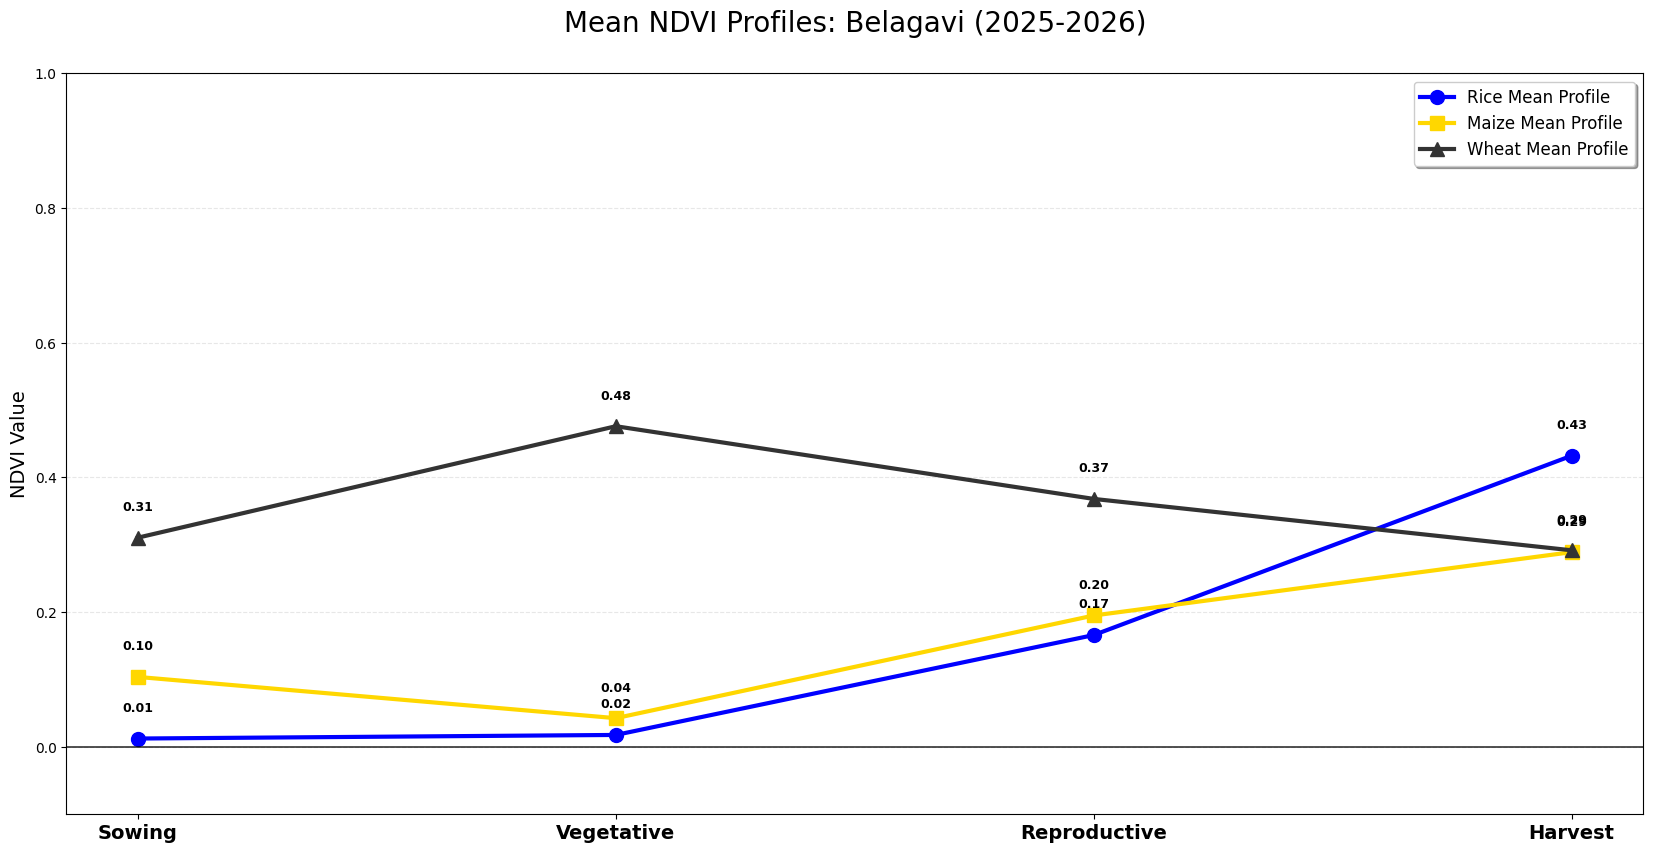

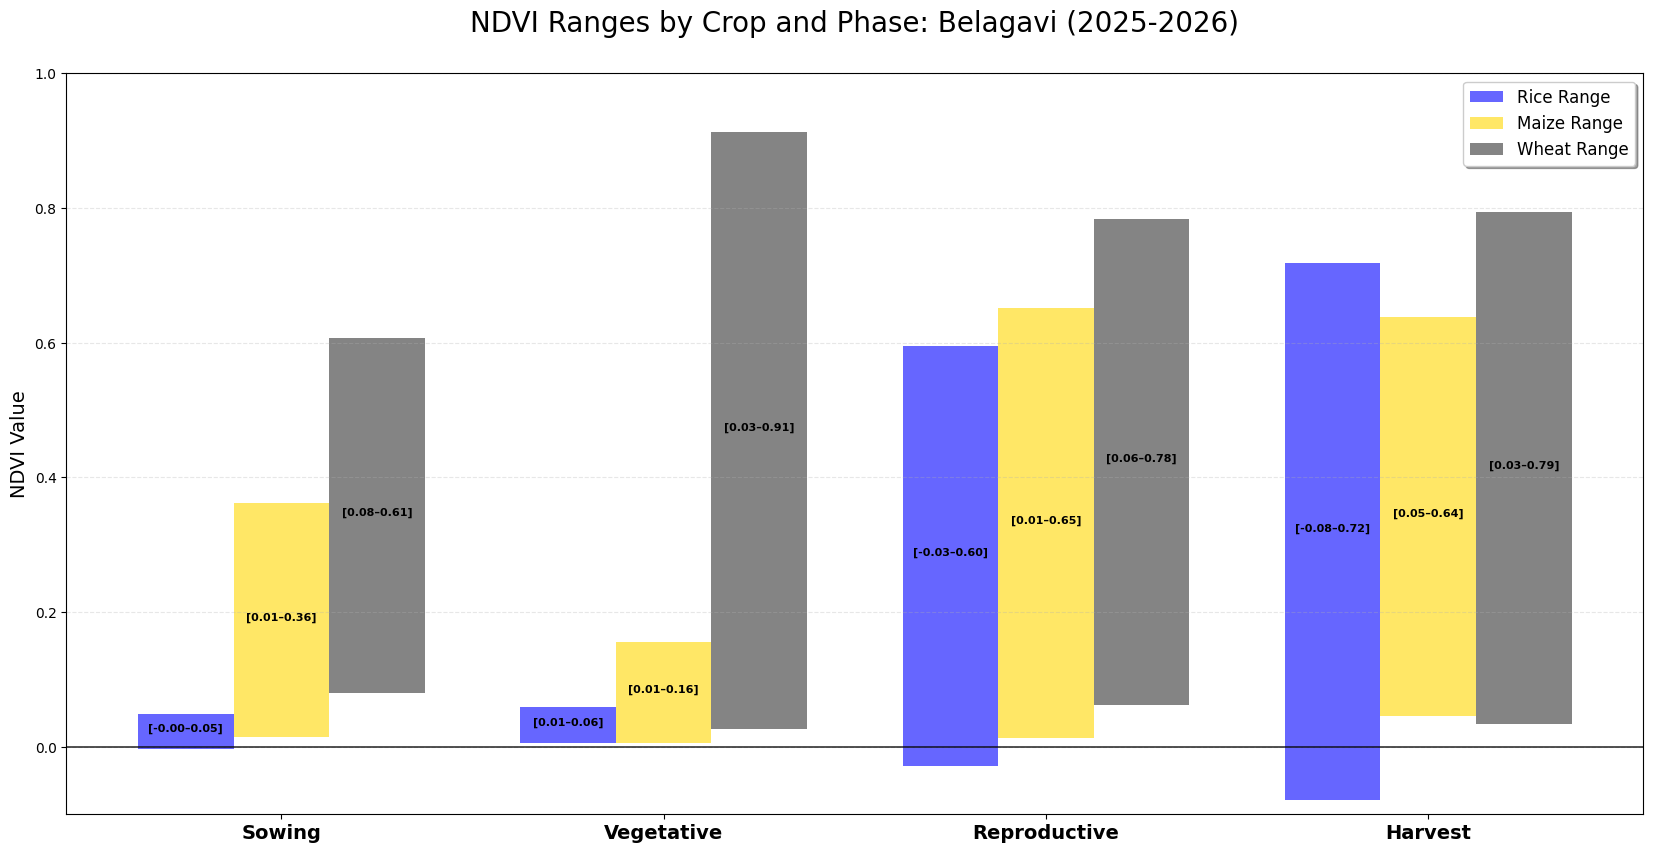

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Define statistical reducer for Range and Mean
range_reducer = ee.Reducer.min().combine(
    reducer2=ee.Reducer.max(), sharedInputs=True
).combine(
    reducer2=ee.Reducer.mean(), sharedInputs=True
)

all_stats = []

# 2. Extract statistics from GEE (Spatial Feature Averaging)
for crop, phases_image in crop_ndvi.items():
    band_names = phases_image.bandNames().getInfo()

    stats = phases_image.reduceRegions(
        collection=crop_polygons[crop],
        reducer=range_reducer,
        scale=10
    ).getInfo()

    for feature in stats['features']:
        p = feature['properties']
        row_data = {'Crop': crop}
        for band in band_names:
            row_data[f'{band}_mean'] = p.get(f'{band}_mean')
            row_data[f'{band}_min'] = p.get(f'{band}_min')
            row_data[f'{band}_max'] = p.get(f'{band}_max')
        all_stats.append(row_data)

df_stats = pd.DataFrame(all_stats)

# Get a list of crop names from the available data
crops = list(crop_ndvi.keys())

# --- SECTION A: PRINTING THE TECHNICAL TABLE ---
print("\n" + "="*85)
print(f"{'CROP TYPE':<12} | {'GROWTH STAGE':<18} | {'MEAN NDVI':<12} | {'RANGE [MIN - MAX]':<20}")
print("="*85)

for crop_name in crops:
    crop_row = df_stats[df_stats['Crop'] == crop_name].dropna(axis=1)
    if not crop_row.empty:
        # We take the first sample's data for the table summary
        data = crop_row.iloc[0]
        # Identify stages dynamically from the column names
        stages = [col.replace('_mean', '') for col in data.index if '_mean' in col]

        for stage in stages:
            m_val = data[f'{stage}_mean']
            mn_val = data[f'{stage}_min']
            mx_val = data[f'{stage}_max']

            # Handling potential None values if data was missing
            m_str = f"{m_val:.4f}" if m_val is not None else "N/A"
            r_str = f"[{mn_val:.3f} - {mx_val:.3f}]" if mn_val is not None else "N/A"

            print(f"{crop_name:<12} | {stage:<18} | {m_str:<12} | {r_str:<20}")
        print("-" * 85)

# --- SECTION B1: MEAN NDVI PROFILE CURVES ---
plt.figure(figsize=(18, 10))
colors = {'Rice': '#0000FF', 'Maize': '#FFD700', 'Wheat': '#333333'}
markers = {'Rice': 'o', 'Maize': 's', 'Wheat': '^'}
stages = ['Sowing', 'Vegetative', 'Reproductive', 'Harvest']
x_numeric = np.arange(1, len(stages) + 1)

for crop in crops:
    crop_row = df_stats[df_stats['Crop'] == crop].dropna(axis=1)
    if crop_row.empty: continue

    data = crop_row.iloc[0]
    means = np.array([data.get(f'{s}_mean') for s in stages])

    # Plot mean profile curve
    plt.plot(x_numeric, means, color=colors[crop], marker=markers[crop],
             linewidth=3, markersize=10, label=f'{crop} Mean Profile')

    # Annotate mean values
    for x, m in zip(x_numeric, means):
        if m is not None:
            plt.text(x, m + 0.04, f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.xticks(x_numeric, stages, fontsize=14, fontweight='bold')
plt.title(f'Mean NDVI Profiles: Belagavi ({YEAR}-{NEXT_YEAR})', fontsize=20, pad=30)
plt.ylabel('NDVI Value', fontsize=14)
plt.ylim(-0.1, 1.0)
plt.axhline(0, color='black', linewidth=1.2, alpha=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', shadow=True, fontsize=12)
plt.tight_layout(pad=6.0)
plt.show()


# --- SECTION B2: NDVI RANGE BAR CHART ---
plt.figure(figsize=(18, 10))
bar_width = 0.25
x_numeric = np.arange(len(stages))

for i, crop in enumerate(crops):
    crop_row = df_stats[df_stats['Crop'] == crop].dropna(axis=1)
    if crop_row.empty: continue

    data = crop_row.iloc[0]
    mins = np.array([data.get(f'{s}_min') for s in stages])
    maxs = np.array([data.get(f'{s}_max') for s in stages])

    # Plot bars for ranges
    plt.bar(x_numeric + i*bar_width, maxs - mins, bottom=mins,
            width=bar_width, color=colors[crop], alpha=0.6, label=f'{crop} Range')

    # Annotate ranges
    for x, mn, mx in zip(x_numeric + i*bar_width, mins, maxs):
        plt.text(x, (mn+mx)/2, f"[{mn:.2f}–{mx:.2f}]",
                 ha='center', fontsize=8, fontweight='bold', color='black')

plt.xticks(x_numeric + bar_width, stages, fontsize=14, fontweight='bold')
plt.title(f'NDVI Ranges by Crop and Phase: Belagavi ({YEAR}-{NEXT_YEAR})', fontsize=20, pad=30)
plt.ylabel('NDVI Value', fontsize=14)
plt.ylim(-0.1, 1.0)
plt.axhline(0, color='black', linewidth=1.2, alpha=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', shadow=True, fontsize=12)
plt.tight_layout(pad=6.0)
plt.show()
